In [1]:
import pandas as pd
import numpy as np
jobs = pd.read_csv("/content/ai_job_trends_dataset.csv")

1.Top 5 lines of above loaded dataset


In [2]:
jobs.head()

,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57


2.Checking Shape of Dataset


In [3]:
jobs.shape

(30000, 13)

3.Checking the Information of a Dataset

In [4]:
jobs.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job Title                    30000 non-null  object 
 1   Industry                     30000 non-null  object 
 2   Job Status                   30000 non-null  object 
 3   AI Impact Level              30000 non-null  object 
 4   Median Salary (USD)          30000 non-null  float64
 5   Required Education           30000 non-null  object 
 6   Experience Required (Years)  30000 non-null  int64  
 7   Job Openings (2024)          30000 non-null  int64  
 8   Projected Openings (2030)    30000 non-null  int64  
 9   Remote Work Ratio (%)        30000 non-null  float64
 10  Automation Risk (%)          30000 non-null  float64
 11  Location                     30000 non-null  object 
 12  Gender Diversity (%)         30000 non-null  float64
dtypes: float64(4), i

4.Checking the Description / Statistics of a dataset


In [5]:
jobs.describe()

,Median Salary (USD),Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Gender Diversity (%)
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,90119.965639,10.051433,5039.640833,5074.218100,49.836431,50.154229,49.979660
std,34412.013953,6.060678,2861.009654,2866.550722,28.966688,28.754889,17.274665
min,30001.860000,0.000000,100.000000,100.000000,0.000000,0.000000,20.000000
25%,60500.702500,5.000000,2570.000000,2586.750000,24.570000,25.400000,35.070000
50%,90274.115000,10.000000,5034.000000,5106.500000,49.570000,50.020000,49.885000
75%,119454.710000,15.000000,7527.000000,7573.000000,75.100000,75.030000,64.910000
max,149998.500000,20.000000,10000.000000,10000.000000,100.000000,99.990000,80.000000


5.Checking whether there are any nulls in the dataset

In [6]:
df1=jobs.isnull().sum()
df1

,0
Job Title,0
Industry,0
Job Status,0
AI Impact Level,0
Median Salary (USD),0
Required Education,0
Experience Required (Years),0
Job Openings (2024),0
Projected Openings (2030),0
Remote Work Ratio (%),0


6.Checking the Industry wise AVG Salary ranges at each AI Impact Level

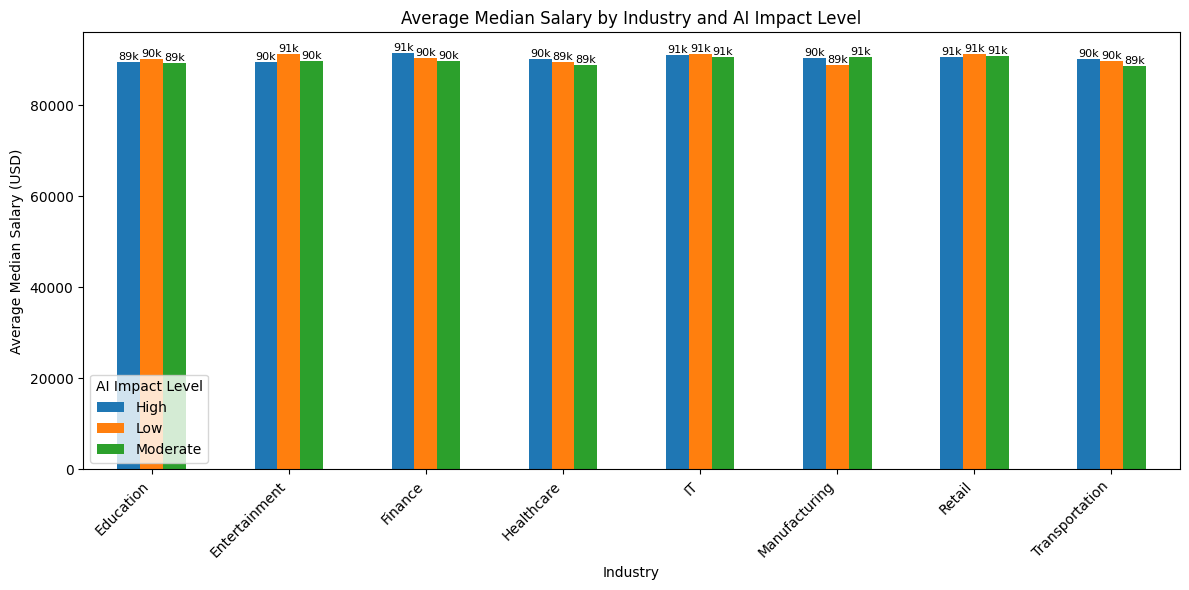

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming `jobs` is our DataFrame

# Step 1: Group by Industry and AI Impact Level, compute average Median Salary
high_avg_sal = jobs.groupby(['Industry', 'AI Impact Level'])['Median Salary (USD)'].mean().sort_values(ascending=False).reset_index()

# Step 2: Pivot the table so that AI Impact Levels become columns (for grouped bars)
pivot_table = high_avg_sal.pivot(index='Industry', columns='AI Impact Level', values='Median Salary (USD)')

# Step 3: Plot grouped bar chart
ax=pivot_table.plot(kind='bar', figsize=(12, 6))

plt.ylabel('Average Median Salary (USD)')
plt.title('Average Median Salary by Industry and AI Impact Level')
plt.xticks(rotation=45, ha='right')
plt.legend(title='AI Impact Level')
plt.tight_layout()

for container in ax.containers:
    labels = [f'{v/1000:.0f}k' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='edge', fontsize=8)
plt.show()



Observations:

Salaries are quite close across AI Impact Levels within each industry.

The values mostly hover around 89,000 dollar  to 91,000 dollar.

For some industries, the highest salary appears under "High" AI Impact Level, while for others it might be "Low" or "Moderate".

The differences between AI impact levels are minimal, typically just
$1,000 or less.



7.Checking location wise "HIGH" AI Impact Level

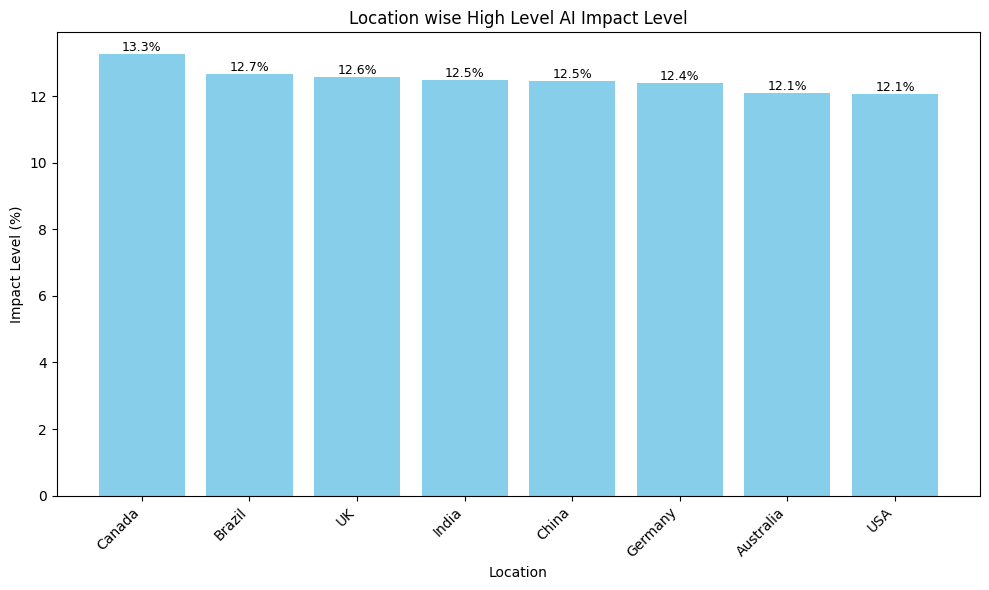

In [8]:
import matplotlib.pyplot as plt

# Filter the DataFrame where AI Impact Level is 'High' and get value counts
counts = jobs[jobs['AI Impact Level'] == 'High']['Location'].value_counts()

# Convert counts to percentages
percentages = (counts / counts.sum()) * 100

# Create figure
plt.figure(figsize=(10, 6))

# Plot column chart (vertical bars)
bars = plt.bar(percentages.index, percentages.values, color='skyblue')

# Add title and labels
plt.title('Location wise High Level AI Impact Level')
plt.xlabel('Location')
plt.ylabel('Impact Level (%)')
plt.xticks(rotation=45, ha='right')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height,
             f'{height:.1f}%',      # Show one decimal place, e.g., 12.3%
             ha='center',
             va='bottom',
             fontsize=9)

plt.tight_layout()
plt.show()


Observations:

The difference between the highest (Canada) and lowest (Australia/USA) is only ~1.2%.

This small variation suggests that the high-level AI impact is relatively uniform across these major economies.

Slightly higher values in Canada and Brazil might reflect either more AI integration in certain sectors, or different survey methods/sampling.


8.Checking Automation Risk by Job Title


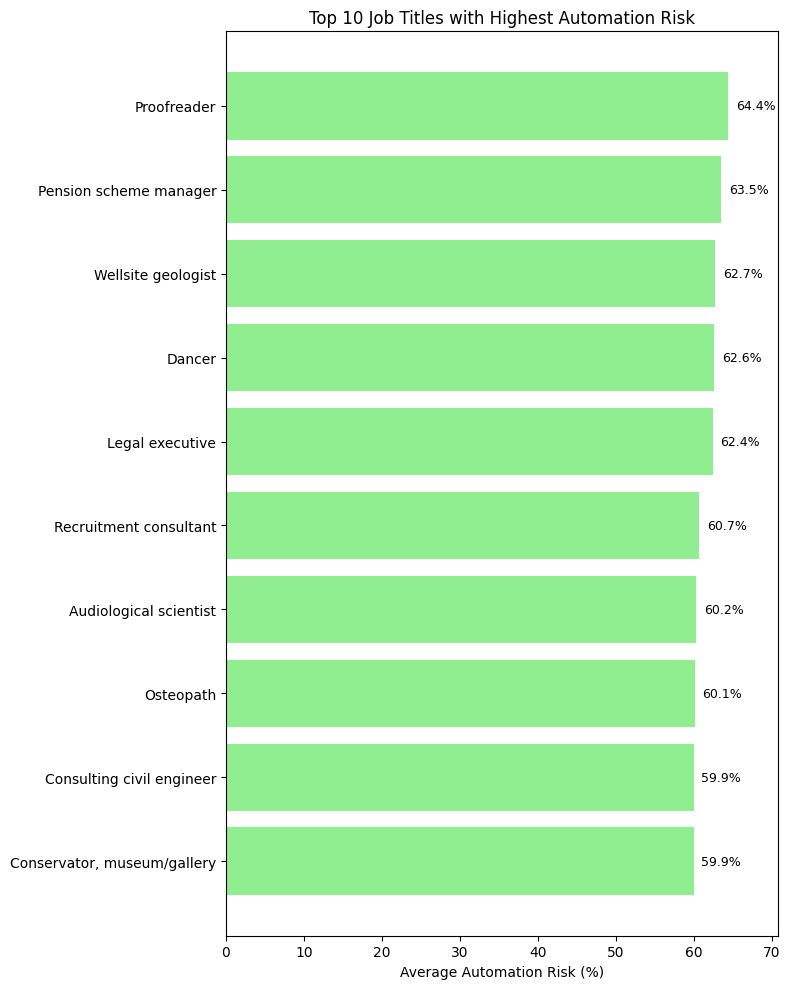

In [9]:
import matplotlib.pyplot as plt

# Calculate top 10
top10 = jobs.groupby('Job Title')['Automation Risk (%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 10))

# Capture the bars
bars = plt.barh(top10.index, top10.values, color='lightgreen')

plt.xlabel('Average Automation Risk (%)')
plt.title('Top 10 Job Titles with Highest Automation Risk')

plt.xlim(0, max(top10.values)*1.1)


# Add value labels next to each bar
for bar in bars:
    width = bar.get_width()  # actual value of this bar
    plt.text(
        width + 1,  # position a little to the right of the bar
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',  # format with one decimal
        ha='left', va='center', fontsize=9
    )

plt.gca().invert_yaxis()  # Highest value at the top
plt.tight_layout()
plt.show()


9.Industry wise Comparision between Current job openings (2024) vs Projected Openings (2030)

<Figure size 1200x600 with 0 Axes>

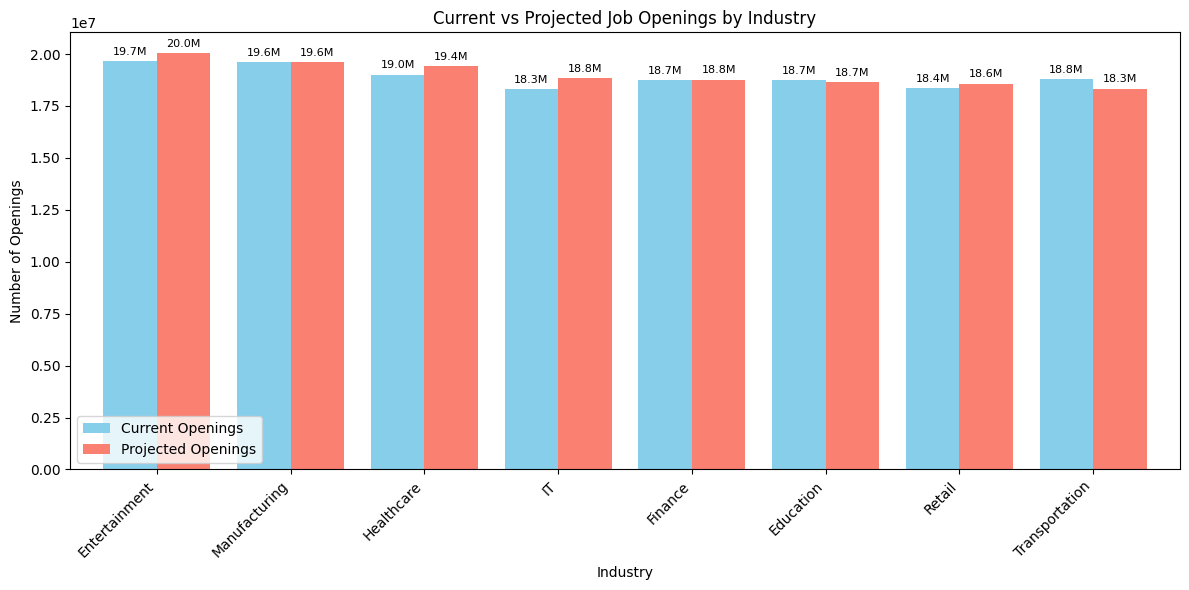

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Group by Industry and sum
current_job_openings = jobs.groupby('Industry')['Job Openings (2024)'].sum()
projected_job_openings = jobs.groupby('Industry')['Projected Openings (2030)'].sum()

# Step 2: Combine into one DataFrame
combined = pd.DataFrame({
    'Current Openings': current_job_openings,
    'Projected Openings': projected_job_openings
})

# Optional: sort by projected openings to make plot clearer
combined = combined.sort_values('Projected Openings', ascending=False)

# Step 3: Plot grouped column chart
plt.figure(figsize=(12, 6))

ax = combined.plot(
    kind='bar',
    figsize=(12, 6),
    color=['skyblue', 'salmon'],
    width=0.8
)

plt.title('Current vs Projected Job Openings by Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Openings')
plt.xticks(rotation=45, ha='right')
plt.legend(title='')

for container in ax.containers:
    labels = [f'{v/1_000_000:.1f}M' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.tight_layout()
plt.show()


Observations:
Overall, most industries show modest growth in job openings.

The Entertainment industry has the highest absolute projected growth.

Transportation is unique in showing a small decline in projected openings, which may reflect automation or efficiency gains.

The differences between current and projected values are small in percentage terms but significant in absolute numbers (hundreds of thousands).
